# Phase 4 — Model Interpretability

**Goal:** Open the best CNN and understand what it actually learned.

This notebook covers:
1. Convolutional filter weight visualization (early, middle, deep layers)
2. Feature map activations — what each layer responds to
3. Grad-CAM — which image regions drive each prediction
4. Comparing attention maps for correct vs wrong predictions

**Model:** `exp5_aug_bn_drop05_b64_best.keras`  
Architecture: 4 conv blocks (32→64→128→128) + BatchNorm + Dropout(0.5)  
Test accuracy: 72.38%

In [1]:
import os, random, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f'TensorFlow {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1779903898.283932    1636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779903898.329959    1636 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779903900.324244    1636 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
if Path.cwd().name == 'notebooks':
    os.chdir('..')

DATA_ROOT   = Path('/home/arman/blood_cell_data')
TEST_DIR    = DATA_ROOT / 'TEST'
FIGS        = Path('outputs/figures')
MODELS_DIR  = Path('saved_models')
FIGS.mkdir(parents=True, exist_ok=True)

CLASSES     = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
COLORS      = ['#4FA3D1', '#5DBB8A', '#E8A838', '#D15F4F']
IMG_SIZE    = (128, 128)
AUTOTUNE    = tf.data.AUTOTUNE
BEST_MODEL  = 'exp5_aug_bn_drop05_b64_best.keras'

print(f'TEST_DIR exists : {TEST_DIR.exists()}')
print(f'Model    exists : {(MODELS_DIR / BEST_MODEL).exists()}')

TEST_DIR exists : True
Model    exists : True


In [3]:
# Load best model
model = tf.keras.models.load_model(MODELS_DIR / BEST_MODEL)
model.summary()

# Print layer index table for easy reference
print('\n--- Layer index | Type | Name ---')
for i, lyr in enumerate(model.layers):
    print(f'  [{i:2d}]  {type(lyr).__name__:<30}  {lyr.name}')

# Collect layers by type for use later
conv_layers = [l for l in model.layers if isinstance(l, tf.keras.layers.Conv2D)]
act_layers  = [l for l in model.layers if isinstance(l, tf.keras.layers.Activation)]

print(f'\nConv2D layers    : {[l.name for l in conv_layers]}')
print(f'Activation layers: {[l.name for l in act_layers]}')

I0000 00:00:1779903902.153301    1636 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "cnn_bn1_do5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,298,094 (8.77 MB)

 Trainable params: 765,796 (2.92 MB)

 Non-trainable params: 704 (2.75 KB)

 Optimizer params: 1,531,594 (5.84 MB)


--- Layer index | Type | Name ---
  [ 0]  InputLayer                      input_layer_6
  [ 1]  Conv2D                          conv2d_20
  [ 2]  BatchNormalization              batch_normalization_12
  [ 3]  Activation                      activation_20
  [ 4]  MaxPooling2D                    max_pooling2d_20
  [ 5]  Conv2D                          conv2d_21
  [ 6]  BatchNormalization              batch_normalization_13
  [ 7]  Activation                      activation_21
  [ 8]  MaxPooling2D                    max_pooling2d_21
  [ 9]  Conv2D                          conv2d_22
  [10]  BatchNormalization              batch_normalization_14
  [11]  Activation                      activation_22
  [12]  MaxPooling2D                    max_pooling2d_22
  [13]  Conv2D                          conv2d_23
  [14]  BatchNormalization              batch_normalization_15
  [15]  Activation                      activation_23
  [16]  MaxPooling2D                    max_pooling2d_23
  [17]  Flatten

In [4]:
# Load test dataset and collect predictions
rescaling = layers.Rescaling(1.0 / 255)

raw_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, batch_size=32, shuffle=False,
    image_size=IMG_SIZE, label_mode='int')

test_ds = raw_ds.map(
    lambda x, y: (rescaling(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

y_true_list, y_proba_list = [], []
for xb, yb in test_ds:
    y_true_list.extend(yb.numpy())
    y_proba_list.extend(model(xb, training=False).numpy())

y_true       = np.array(y_true_list)
y_pred_proba = np.array(y_proba_list)
y_pred       = np.argmax(y_pred_proba, axis=1)

# Reconstruct file paths in the same order as image_dataset_from_directory
test_filepaths = []
for cls in sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir()]):
    cls_dir = TEST_DIR / cls
    test_filepaths.extend(sorted(
        [f for f in cls_dir.iterdir()
         if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    ))
test_filepaths = np.array(test_filepaths)

print(f'Total test samples : {len(y_true)}')
print(f'Overall accuracy   : {(y_true == y_pred).mean():.4f}')
print()
for i, cls in enumerate(CLASSES):
    mask = (y_true == i)
    acc_i = (y_pred[mask] == y_true[mask]).mean()
    n_ok  = (y_pred[mask] == y_true[mask]).sum()
    print(f'  {cls:<14}: acc={acc_i:.4f}  ({n_ok}/{mask.sum()})')

Found 2487 files belonging to 4 classes.


I0000 00:00:1779903903.300288    1636 cuda_dnn.cc:461] Loaded cuDNN version 92200


Total test samples : 2487
Overall accuracy   : 0.7238

  EOSINOPHIL    : acc=0.6613  (412/623)
  LYMPHOCYTE    : acc=0.5387  (334/620)
  MONOCYTE      : acc=0.7210  (447/620)
  NEUTROPHIL    : acc=0.9728  (607/624)


## 2. Convolutional Filter Visualization

The learned 3x3 filter weights tell us what low-level patterns each conv layer is looking for.

- **Block 1 (early)**: filters have shape (3,3,3) — directly visualizable as small RGB patches.
- **Block 2 (middle)** and **Block 4 (deep)**: filters have many input channels — we show the L2 norm
  across all input channels to get a single magnitude map per filter.

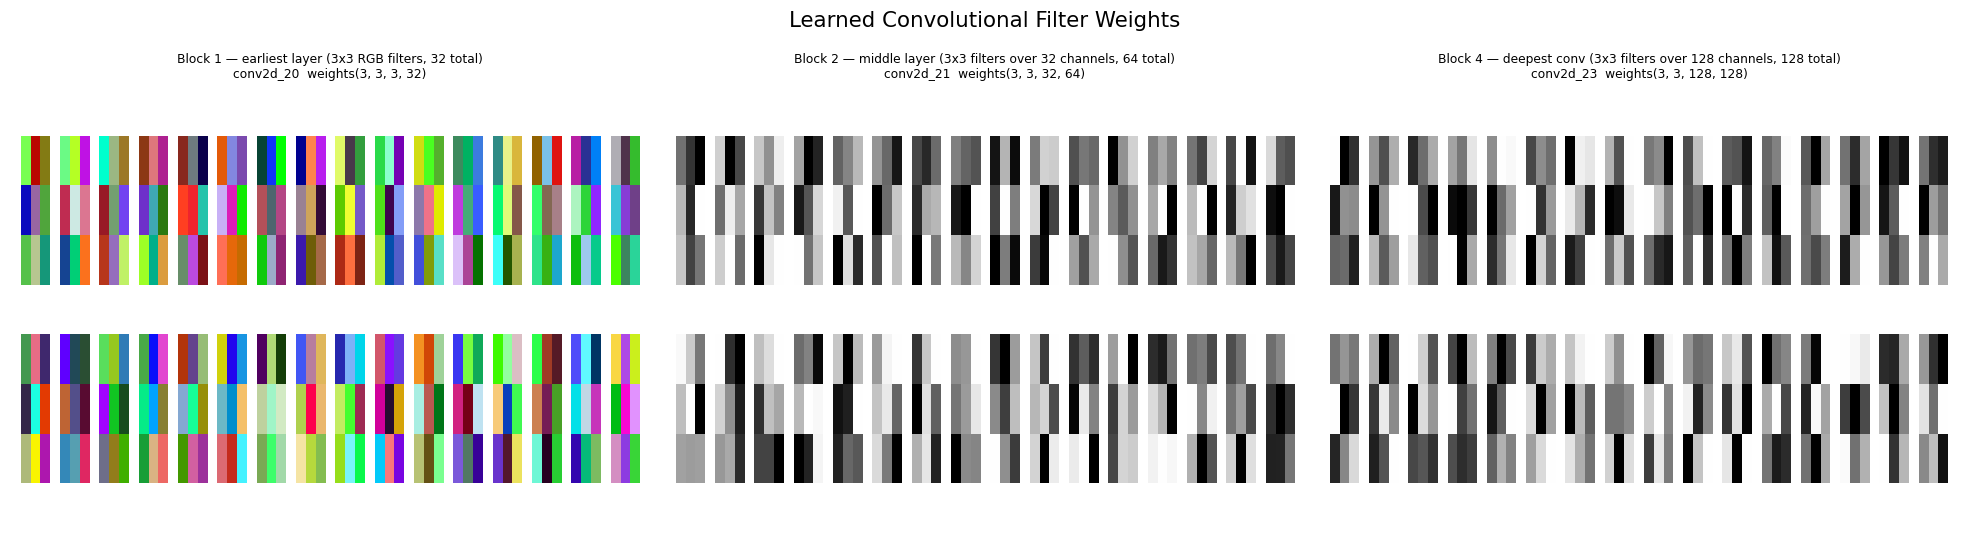

saved -> outputs/figures/phase4_01_conv_filters.png


In [5]:
def normalize_to_01(arr):
    """Normalize array to [0, 1] range."""
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-8)


def make_filter_grid(weights, n_show=32, n_cols=16):
    """
    Build a grid image of filter weights.
    weights: (kH, kW, C_in, C_out)
    For C_in=3: show as color patches.
    For C_in>3: show L2 norm across input channels (grayscale).
    Returns: (grid_H, grid_W, 3) float image.
    """
    kH, kW, C_in, C_out = weights.shape
    n_show  = min(n_show, C_out)
    n_rows  = (n_show + n_cols - 1) // n_cols
    pad     = 1
    cell    = kH + pad

    grid = np.ones((n_rows * cell + pad, n_cols * cell + pad, 3))

    for idx in range(n_show):
        r = idx // n_cols
        c = idx % n_cols
        f = weights[:, :, :, idx]  # (kH, kW, C_in)

        if C_in == 3:
            patch = normalize_to_01(f)           # (kH, kW, 3)
        else:
            mag   = np.linalg.norm(f, axis=-1)   # (kH, kW)
            mag   = normalize_to_01(mag)
            patch = np.stack([mag, mag, mag], axis=-1)

        rs = r * cell + pad
        cs = c * cell + pad
        grid[rs:rs + kH, cs:cs + kW] = patch

    return grid


# Visualize 3 conv layers: block 1 (early), block 2 (middle), block 4 (deep)
selected_indices = [0, 1, 3]   # indices into conv_layers list
layer_titles = [
    'Block 1 — earliest layer (3x3 RGB filters, 32 total)',
    'Block 2 — middle layer (3x3 filters over 32 channels, 64 total)',
    'Block 4 — deepest conv (3x3 filters over 128 channels, 128 total)',
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learned Convolutional Filter Weights', fontsize=14)

for ax, conv_idx, title in zip(axes, selected_indices, layer_titles):
    lyr     = conv_layers[conv_idx]
    weights = lyr.get_weights()[0]   # (kH, kW, C_in, C_out)
    grid    = make_filter_grid(weights, n_show=32, n_cols=16)
    ax.imshow(grid, interpolation='nearest', aspect='auto')
    ax.set_title(f'{title}\n{lyr.name}  weights{weights.shape}',
                 fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig(FIGS / 'phase4_01_conv_filters.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase4_01_conv_filters.png')

## 3. Feature Map Activations

Feature maps show what each layer's neurons actually respond to when a specific image is passed through.

We build intermediate models that output the post-ReLU activations after each conv block,
then visualize the first 16 channels at each stage for one representative image per class.

**Stages:**
- Stage 1 (after Block 1 relu): spatial size 64×64, 32 channels
- Stage 2 (after Block 2 relu): spatial size 32×32, 64 channels
- Stage 3 (after Block 3 relu): spatial size 16×16, 128 channels
- Stage 4 (after Block 4 relu): spatial size 8×8, 128 channels

In [6]:
# Build 4 intermediate models (one per activation stage)
stage_models = [
    tf.keras.Model(inputs=model.input, outputs=act_lyr.output)
    for act_lyr in act_layers
]

# Read actual spatial dimensions from layer output shapes
stage_labels = []
for lyr in act_layers:
    s = lyr.output.shape
    stage_labels.append(f"{lyr.name}({s[1]}x{s[2]}, {s[3]}ch)")

print("Activation stages:")
for lbl in stage_labels:
    print(" ", lbl.replace("", "  "))

# Pick one correctly-classified sample per class (highest confidence)
sample_indices = []
for cls_idx in range(len(CLASSES)):
    mask_correct = (y_true == cls_idx) & (y_pred == cls_idx)
    cands = np.where(mask_correct)[0]
    if len(cands) == 0:
        cands = np.where(y_true == cls_idx)[0]
    best = cands[np.argmax(y_pred_proba[cands, cls_idx])]
    sample_indices.append(best)

print("Selected sample indices (one per class):")
for cls_idx, idx in enumerate(sample_indices):
    print(f"  {CLASSES[cls_idx]:<14}: idx={idx}, ",
          f"true={CLASSES[y_true[idx]]}, pred={CLASSES[y_pred[idx]]}, ",
          f"conf={y_pred_proba[idx, y_pred[idx]]:.3f}")


Activation stages:
    a  c  t  i  v  a  t  i  o  n  _  2  0  (  1  2  8  x  1  2  8  ,     3  2  c  h  )  
    a  c  t  i  v  a  t  i  o  n  _  2  1  (  6  4  x  6  4  ,     6  4  c  h  )  
    a  c  t  i  v  a  t  i  o  n  _  2  2  (  3  2  x  3  2  ,     1  2  8  c  h  )  
    a  c  t  i  v  a  t  i  o  n  _  2  3  (  1  6  x  1  6  ,     1  2  8  c  h  )  
Selected sample indices (one per class):
  EOSINOPHIL    : idx=434,  true=EOSINOPHIL, pred=EOSINOPHIL,  conf=1.000
  LYMPHOCYTE    : idx=654,  true=LYMPHOCYTE, pred=LYMPHOCYTE,  conf=1.000
  MONOCYTE      : idx=1692,  true=MONOCYTE, pred=MONOCYTE,  conf=1.000
  NEUTROPHIL    : idx=1900,  true=NEUTROPHIL, pred=NEUTROPHIL,  conf=1.000


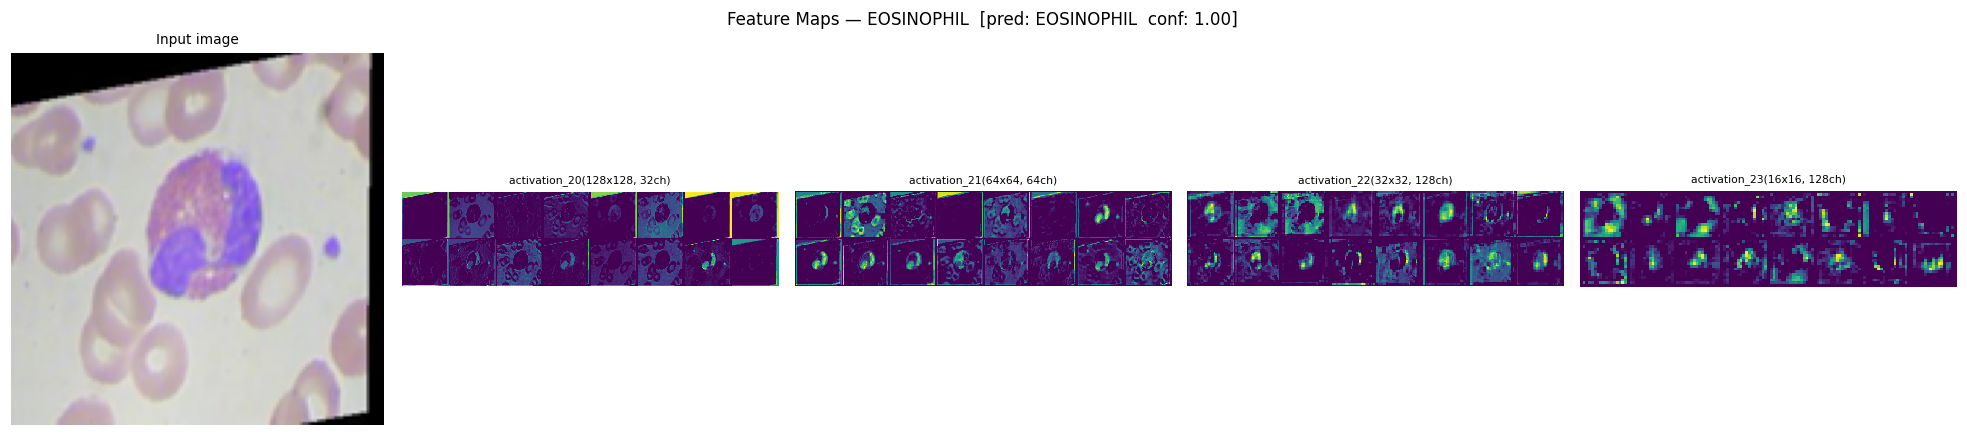

saved -> outputs/figures/phase4_02_feature_maps_eosinophil.png


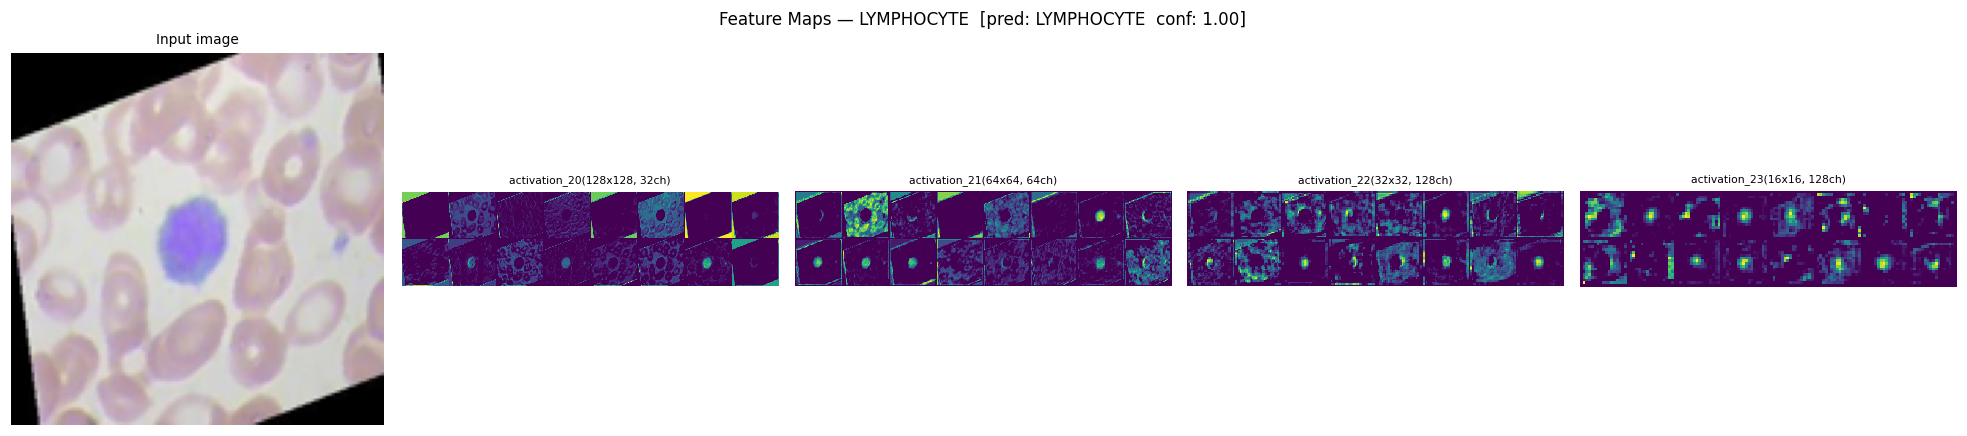

saved -> outputs/figures/phase4_02_feature_maps_lymphocyte.png


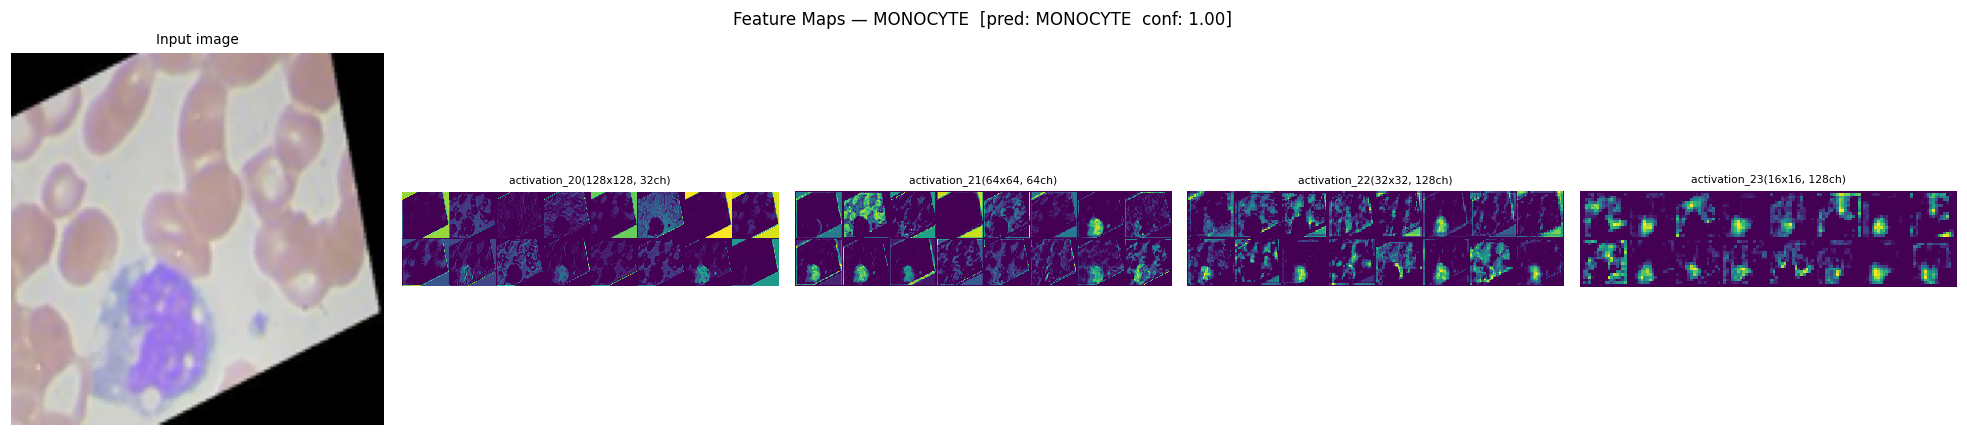

saved -> outputs/figures/phase4_02_feature_maps_monocyte.png


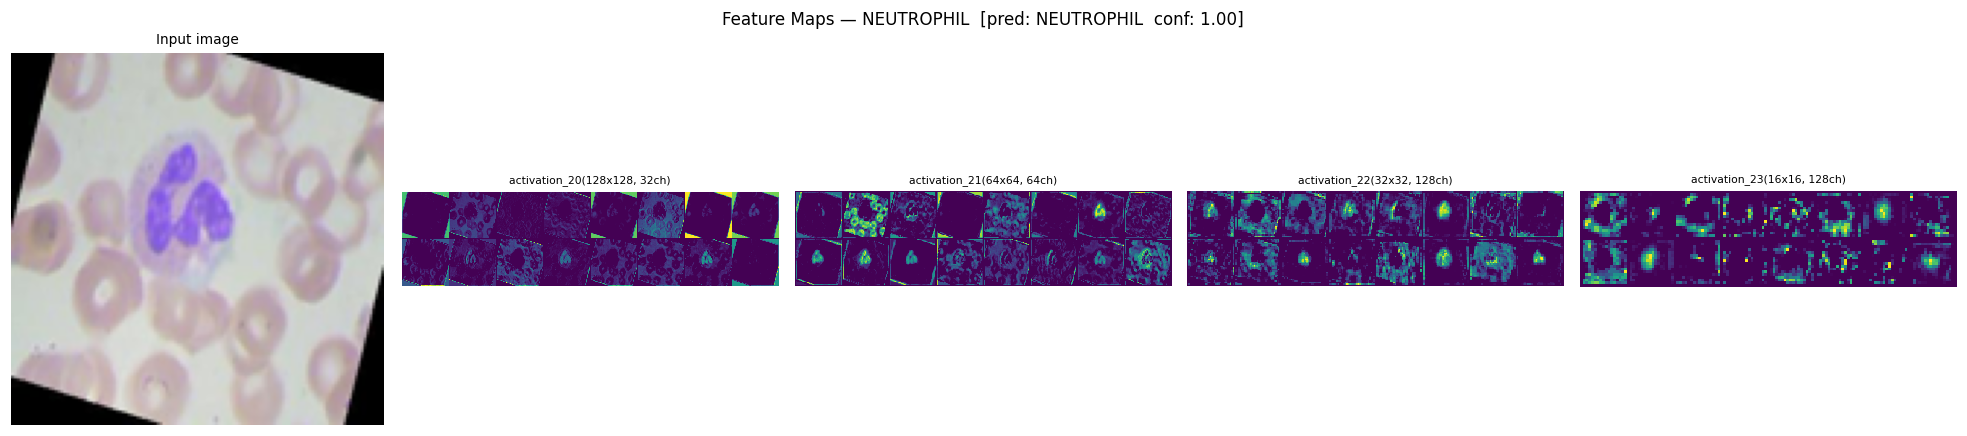

saved -> outputs/figures/phase4_02_feature_maps_neutrophil.png


In [7]:
def preprocess_image(img_path):
    """Load and preprocess a single image for model input."""
    img = np.array(Image.open(img_path).resize(IMG_SIZE)).astype(np.float32) / 255.0
    return img[np.newaxis, ...]   # (1, H, W, 3)


def make_activation_grid(activations, n_show=16, n_cols=8):
    """
    Build a grid image from a batch of feature maps.
    activations: (H, W, C) numpy array
    Returns: (grid_H, grid_W) float image.
    """
    H, W, C = activations.shape
    n_show  = min(n_show, C)
    n_rows  = (n_show + n_cols - 1) // n_cols
    pad     = 1

    grid = np.zeros((n_rows * (H + pad) + pad, n_cols * (W + pad) + pad))

    for idx in range(n_show):
        r = idx // n_cols
        c = idx % n_cols
        ch = activations[:, :, idx]
        ch_norm = normalize_to_01(ch)
        rs = r * (H + pad) + pad
        cs = c * (W + pad) + pad
        grid[rs:rs + H, cs:cs + W] = ch_norm

    return grid


# One figure per class: 1 row of original + 4 stage grids
for cls_idx, sample_idx in enumerate(sample_indices):
    img_path   = test_filepaths[sample_idx]
    img_input  = preprocess_image(img_path)
    orig_img   = np.array(Image.open(img_path).resize(IMG_SIZE))

    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    cls_name   = CLASSES[cls_idx]
    fig.suptitle(
        f'Feature Maps — {cls_name}  '
        f'[pred: {CLASSES[y_pred[sample_idx]]}  conf: {y_pred_proba[sample_idx, y_pred[sample_idx]]:.2f}]',
        fontsize=11
    )

    # Column 0: original image
    axes[0].imshow(orig_img)
    axes[0].set_title('Input image', fontsize=9)
    axes[0].axis('off')

    # Columns 1-4: activation stages
    for stage_idx, (stage_model, stage_label) in enumerate(zip(stage_models, stage_labels)):
        act = stage_model(img_input, training=False).numpy()[0]  # (H, W, C)
        grid = make_activation_grid(act, n_show=16, n_cols=8)
        axes[stage_idx + 1].imshow(grid, cmap='viridis', interpolation='nearest')
        axes[stage_idx + 1].set_title(stage_label, fontsize=7)
        axes[stage_idx + 1].axis('off')

    plt.tight_layout()
    save_path = FIGS / f'phase4_02_feature_maps_{cls_name.lower()}.png'
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'saved -> {save_path}')

## 4. Grad-CAM

**Grad-CAM** (Gradient-weighted Class Activation Mapping, Selvaraju et al. 2017) produces a coarse
localization map showing which spatial regions were most important for the model's prediction.

**Algorithm:**
1. Forward pass: obtain the last conv layer's feature maps and the output class scores.
2. Backpropagate to get gradients of the target class score w.r.t. each feature map.
3. Global-average-pool those gradients → importance weight per channel.
4. Weighted sum of feature maps → raw heatmap.
5. Apply ReLU (keep only positive influence regions), resize to input resolution, overlay.

We use **`activation_3`** (output of Block 4 after BatchNorm + ReLU, spatial size 8×8) as the target layer.

In [8]:
# ---- Grad-CAM helpers ----

# Build grad model once (last activation layer = act_layers[-1])
GRADCAM_LAYER = act_layers[-1]   # activation after last conv block

grad_model = tf.keras.Model(
    inputs=model.input,
    outputs=[GRADCAM_LAYER.output, model.output]
)

print(f'Grad-CAM target layer : {GRADCAM_LAYER.name}')
print(f'Feature map spatial   : {GRADCAM_LAYER.output.shape[1:3]}')


def make_gradcam_heatmap(img_preprocessed, class_idx=None):
    """
    Compute Grad-CAM heatmap.

    img_preprocessed : np.array  shape (1, H, W, 3)  values in [0, 1]
    class_idx        : int, class to explain (None -> use argmax)

    Returns: (heatmap, pred_class_idx)
        heatmap: np.array  shape (h, w)  values in [0, 1]
    """
    img_tensor = tf.constant(img_preprocessed, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        if class_idx is None:
            class_idx = int(tf.argmax(predictions[0]).numpy())
        class_score = predictions[:, class_idx]

    grads = tape.gradient(class_score, conv_outputs)      # (1, h, w, C)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)

    conv_np = conv_outputs[0].numpy()       # (h, w, C)
    grads_np = pooled_grads.numpy()         # (C,)

    # Weighted sum over channels
    heatmap = np.sum(conv_np * grads_np[np.newaxis, np.newaxis, :], axis=-1)  # (h, w)
    heatmap  = np.maximum(heatmap, 0)       # ReLU

    hm_max = heatmap.max()
    if hm_max > 0:
        heatmap /= hm_max

    return heatmap, class_idx


def overlay_gradcam(img_path, heatmap, alpha=0.45):
    """
    Overlay Grad-CAM heatmap on original image.

    Returns: (orig_rgb, overlay_rgb)  both np.uint8 arrays (H, W, 3)
    """
    orig = np.array(Image.open(img_path).resize(IMG_SIZE))

    # Resize heatmap (8x8) to image resolution (128x128)
    hm_pil = Image.fromarray(np.uint8(255 * heatmap))
    hm_pil = hm_pil.resize(IMG_SIZE, Image.BILINEAR)
    hm_arr = np.array(hm_pil) / 255.0      # (H, W)

    # Colorize with jet colormap
    cmap    = plt.get_cmap('jet')
    hm_rgb  = cmap(hm_arr)[:, :, :3]       # (H, W, 3) float

    # Blend
    orig_f  = orig.astype(float) / 255.0
    blended = (1 - alpha) * orig_f + alpha * hm_rgb
    blended = np.clip(blended * 255, 0, 255).astype(np.uint8)

    return orig, blended


# Quick smoke-test on one image
test_img = preprocess_image(test_filepaths[sample_indices[1]])  # LYMPHOCYTE
hm, pred = make_gradcam_heatmap(test_img)
print(f'Heatmap shape : {hm.shape}, range [{hm.min():.3f}, {hm.max():.3f}]')
print(f'Predicted class : {CLASSES[pred]}')

Grad-CAM target layer : activation_23
Feature map spatial   : (16, 16)
Heatmap shape : (16, 16), range [0.000, 1.000]
Predicted class : LYMPHOCYTE


### 4.1 Grad-CAM on Correct Predictions

For each class, pick the 2 correct predictions with highest confidence.
Shows where the model looks when it gets the answer right.

In [9]:
# Collect 2 high-confidence correct predictions per class
correct_samples = []   # list of (img_path, true_cls, pred_cls, conf)

for cls_idx in range(len(CLASSES)):
    mask = (y_true == cls_idx) & (y_pred == cls_idx)
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        continue
    # Sort by confidence (descending), take top 2
    sorted_idxs = idxs[np.argsort(y_pred_proba[idxs, cls_idx])[::-1]]
    for idx in sorted_idxs[:2]:
        correct_samples.append((
            test_filepaths[idx],
            y_true[idx],
            y_pred[idx],
            y_pred_proba[idx, y_pred[idx]]
        ))

print(f'Total correct samples selected: {len(correct_samples)}')
for fp, t, p, c in correct_samples:
    print(f'  true={CLASSES[t]:<14}  pred={CLASSES[p]:<14}  conf={c:.4f}')

Total correct samples selected: 8
  true=EOSINOPHIL      pred=EOSINOPHIL      conf=1.0000
  true=EOSINOPHIL      pred=EOSINOPHIL      conf=0.9999
  true=LYMPHOCYTE      pred=LYMPHOCYTE      conf=1.0000
  true=LYMPHOCYTE      pred=LYMPHOCYTE      conf=1.0000
  true=MONOCYTE        pred=MONOCYTE        conf=1.0000
  true=MONOCYTE        pred=MONOCYTE        conf=1.0000
  true=NEUTROPHIL      pred=NEUTROPHIL      conf=1.0000
  true=NEUTROPHIL      pred=NEUTROPHIL      conf=1.0000


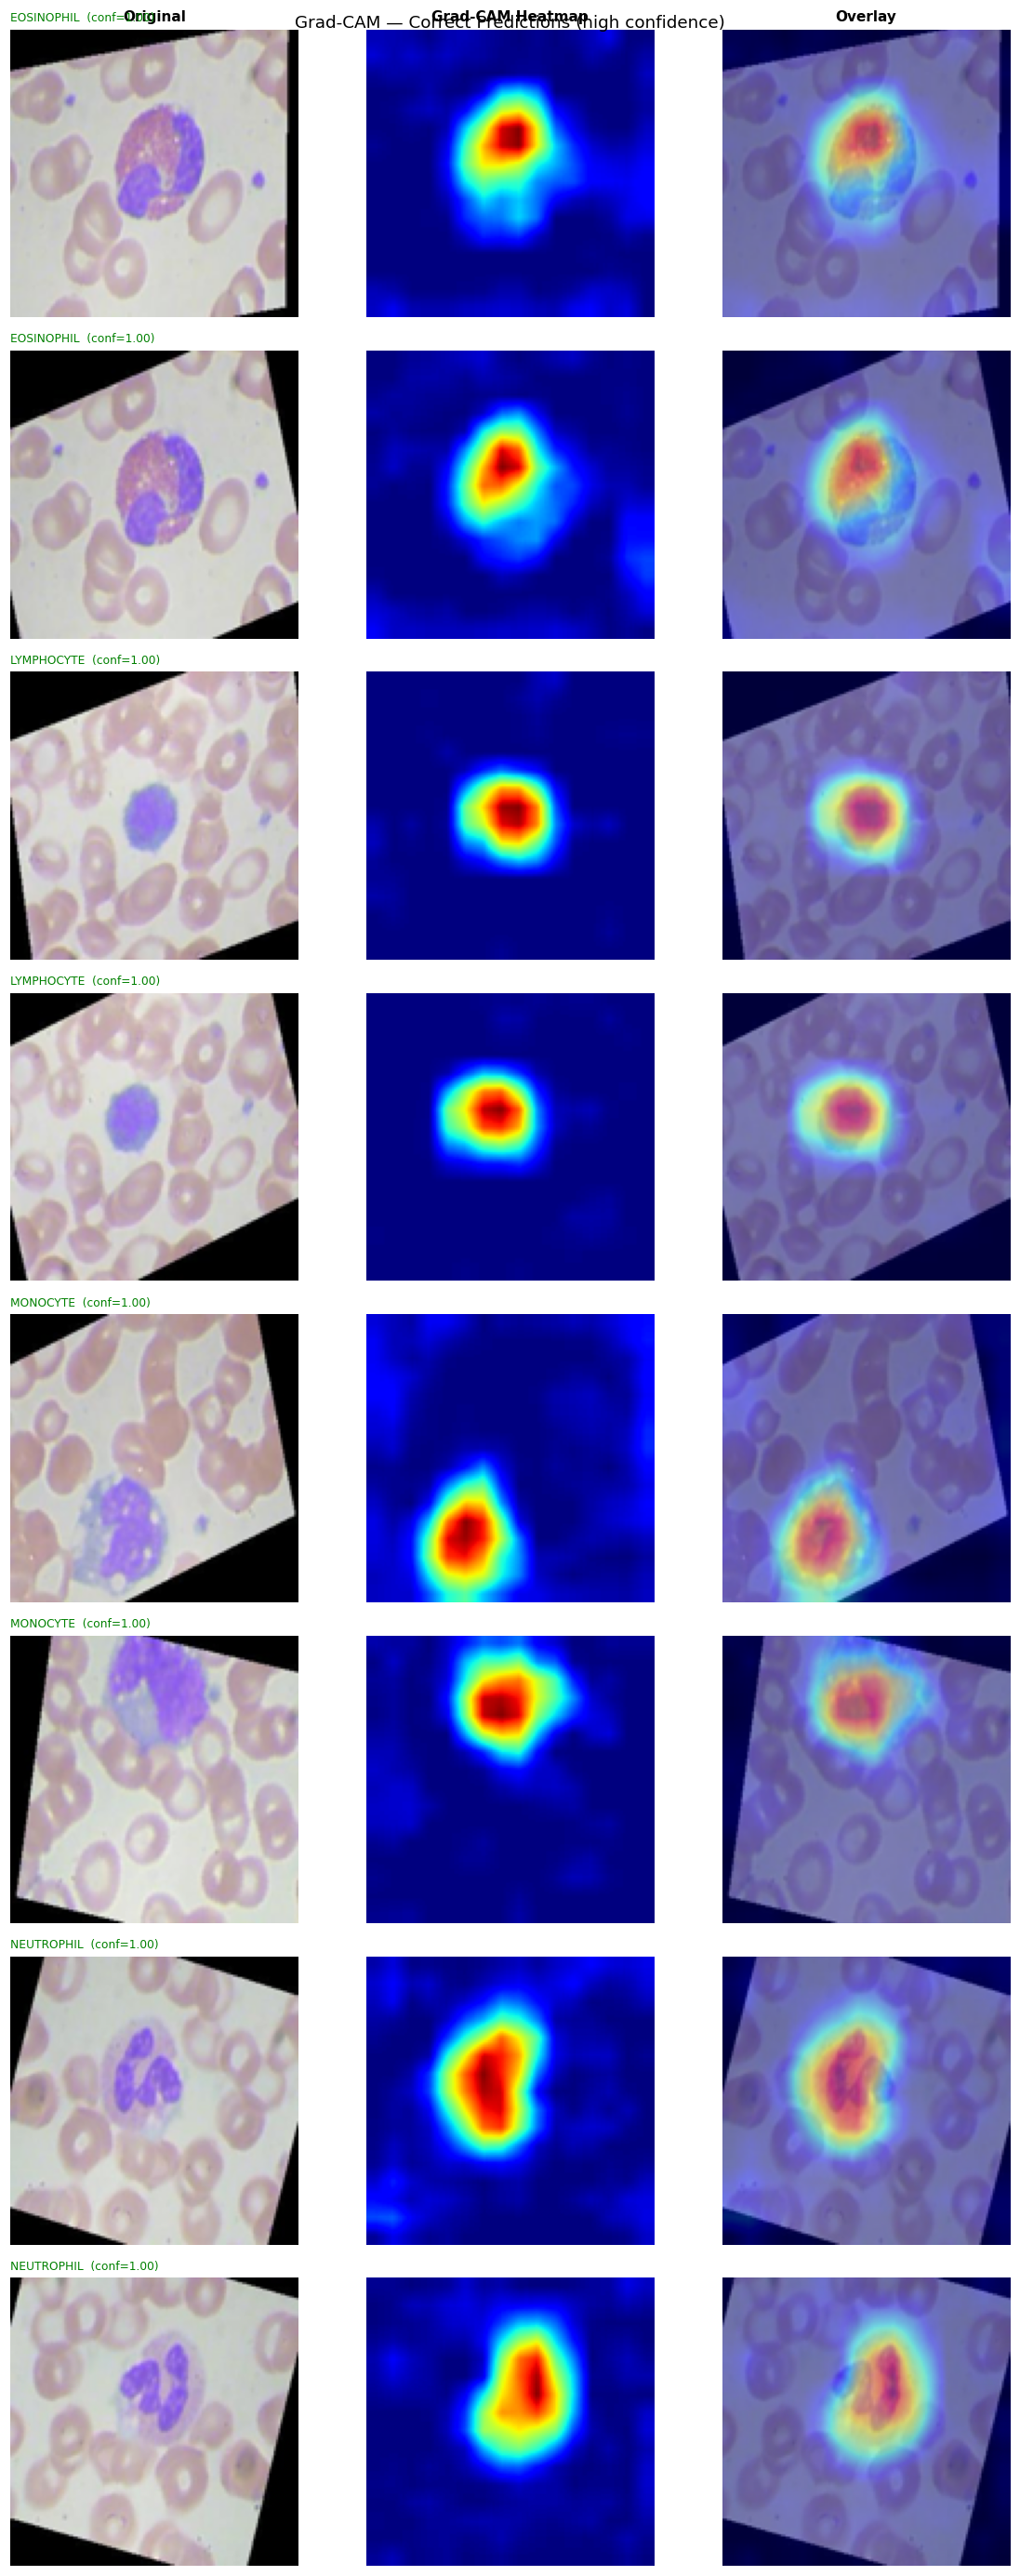

saved -> outputs/figures/phase4_03_gradcam_correct.png


In [10]:
# Plot Grad-CAM for correct predictions
n_samples = len(correct_samples)
fig, axes  = plt.subplots(n_samples, 3, figsize=(11, 3.2 * n_samples))
if n_samples == 1:
    axes = axes[np.newaxis, :]

axes[0, 0].set_title("Original",        fontsize=10, fontweight="bold")
axes[0, 1].set_title("Grad-CAM Heatmap", fontsize=10, fontweight="bold")
axes[0, 2].set_title("Overlay",          fontsize=10, fontweight="bold")

for row, (fp, t, p, conf) in enumerate(correct_samples):
    img_input = preprocess_image(fp)
    heatmap, _ = make_gradcam_heatmap(img_input, class_idx=int(p))
    orig, overlay = overlay_gradcam(fp, heatmap)
    hm_display = np.array(Image.fromarray(np.uint8(255 * heatmap)).resize(IMG_SIZE, Image.BILINEAR))

    row_title = f"{CLASSES[t]}  (conf={conf:.2f})"
    axes[row, 0].set_title(row_title, fontsize=8, color="green", loc="left")
    axes[row, 0].imshow(orig)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(hm_display, cmap="jet", vmin=0, vmax=255)
    axes[row, 1].axis("off")
    axes[row, 2].imshow(overlay)
    axes[row, 2].axis("off")

fig.suptitle("Grad-CAM — Correct Predictions (high confidence)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / "phase4_03_gradcam_correct.png", bbox_inches="tight", dpi=150)
plt.show()
print("saved -> outputs/figures/phase4_03_gradcam_correct.png")


### 4.2 Grad-CAM on Wrong Predictions

The most common errors from Phase 3:
- **LYMPHOCYTE → NEUTROPHIL** (recall=0.55 → ~45% of LYMPHOCYTE missed)
- **EOSINOPHIL → NEUTROPHIL** (recall=0.66)

We show Grad-CAM for these misclassifications to see where the model's attention went wrong.

In [11]:
# Collect wrong predictions — focus on the most common error pairs
# Priority: LYMPH->NEUT, EOSI->NEUT, then any other errors
wrong_samples = []

priority_pairs = [
    (1, 3),  # LYMPHOCYTE predicted as NEUTROPHIL
    (0, 3),  # EOSINOPHIL predicted as NEUTROPHIL
    (2, 3),  # MONOCYTE predicted as NEUTROPHIL
    (3, 0),  # NEUTROPHIL predicted as EOSINOPHIL
]

for true_cls, pred_cls in priority_pairs:
    mask = (y_true == true_cls) & (y_pred == pred_cls)
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        continue
    # Sort by confidence of the WRONG prediction (most confidently wrong first)
    sorted_idxs = idxs[np.argsort(y_pred_proba[idxs, pred_cls])[::-1]]
    for idx in sorted_idxs[:2]:
        wrong_samples.append((
            test_filepaths[idx],
            y_true[idx],
            y_pred[idx],
            y_pred_proba[idx, y_pred[idx]]
        ))
        if len(wrong_samples) >= 8:
            break
    if len(wrong_samples) >= 8:
        break

print(f'Total wrong samples selected: {len(wrong_samples)}')
for fp, t, p, c in wrong_samples:
    print(f'  TRUE={CLASSES[t]:<14}  PRED={CLASSES[p]:<14}  conf={c:.4f}')

Total wrong samples selected: 8
  TRUE=LYMPHOCYTE      PRED=NEUTROPHIL      conf=0.8956
  TRUE=LYMPHOCYTE      PRED=NEUTROPHIL      conf=0.8147
  TRUE=EOSINOPHIL      PRED=NEUTROPHIL      conf=0.9868
  TRUE=EOSINOPHIL      PRED=NEUTROPHIL      conf=0.9789
  TRUE=MONOCYTE        PRED=NEUTROPHIL      conf=0.9964
  TRUE=MONOCYTE        PRED=NEUTROPHIL      conf=0.9961
  TRUE=NEUTROPHIL      PRED=EOSINOPHIL      conf=0.8119
  TRUE=NEUTROPHIL      PRED=EOSINOPHIL      conf=0.7653


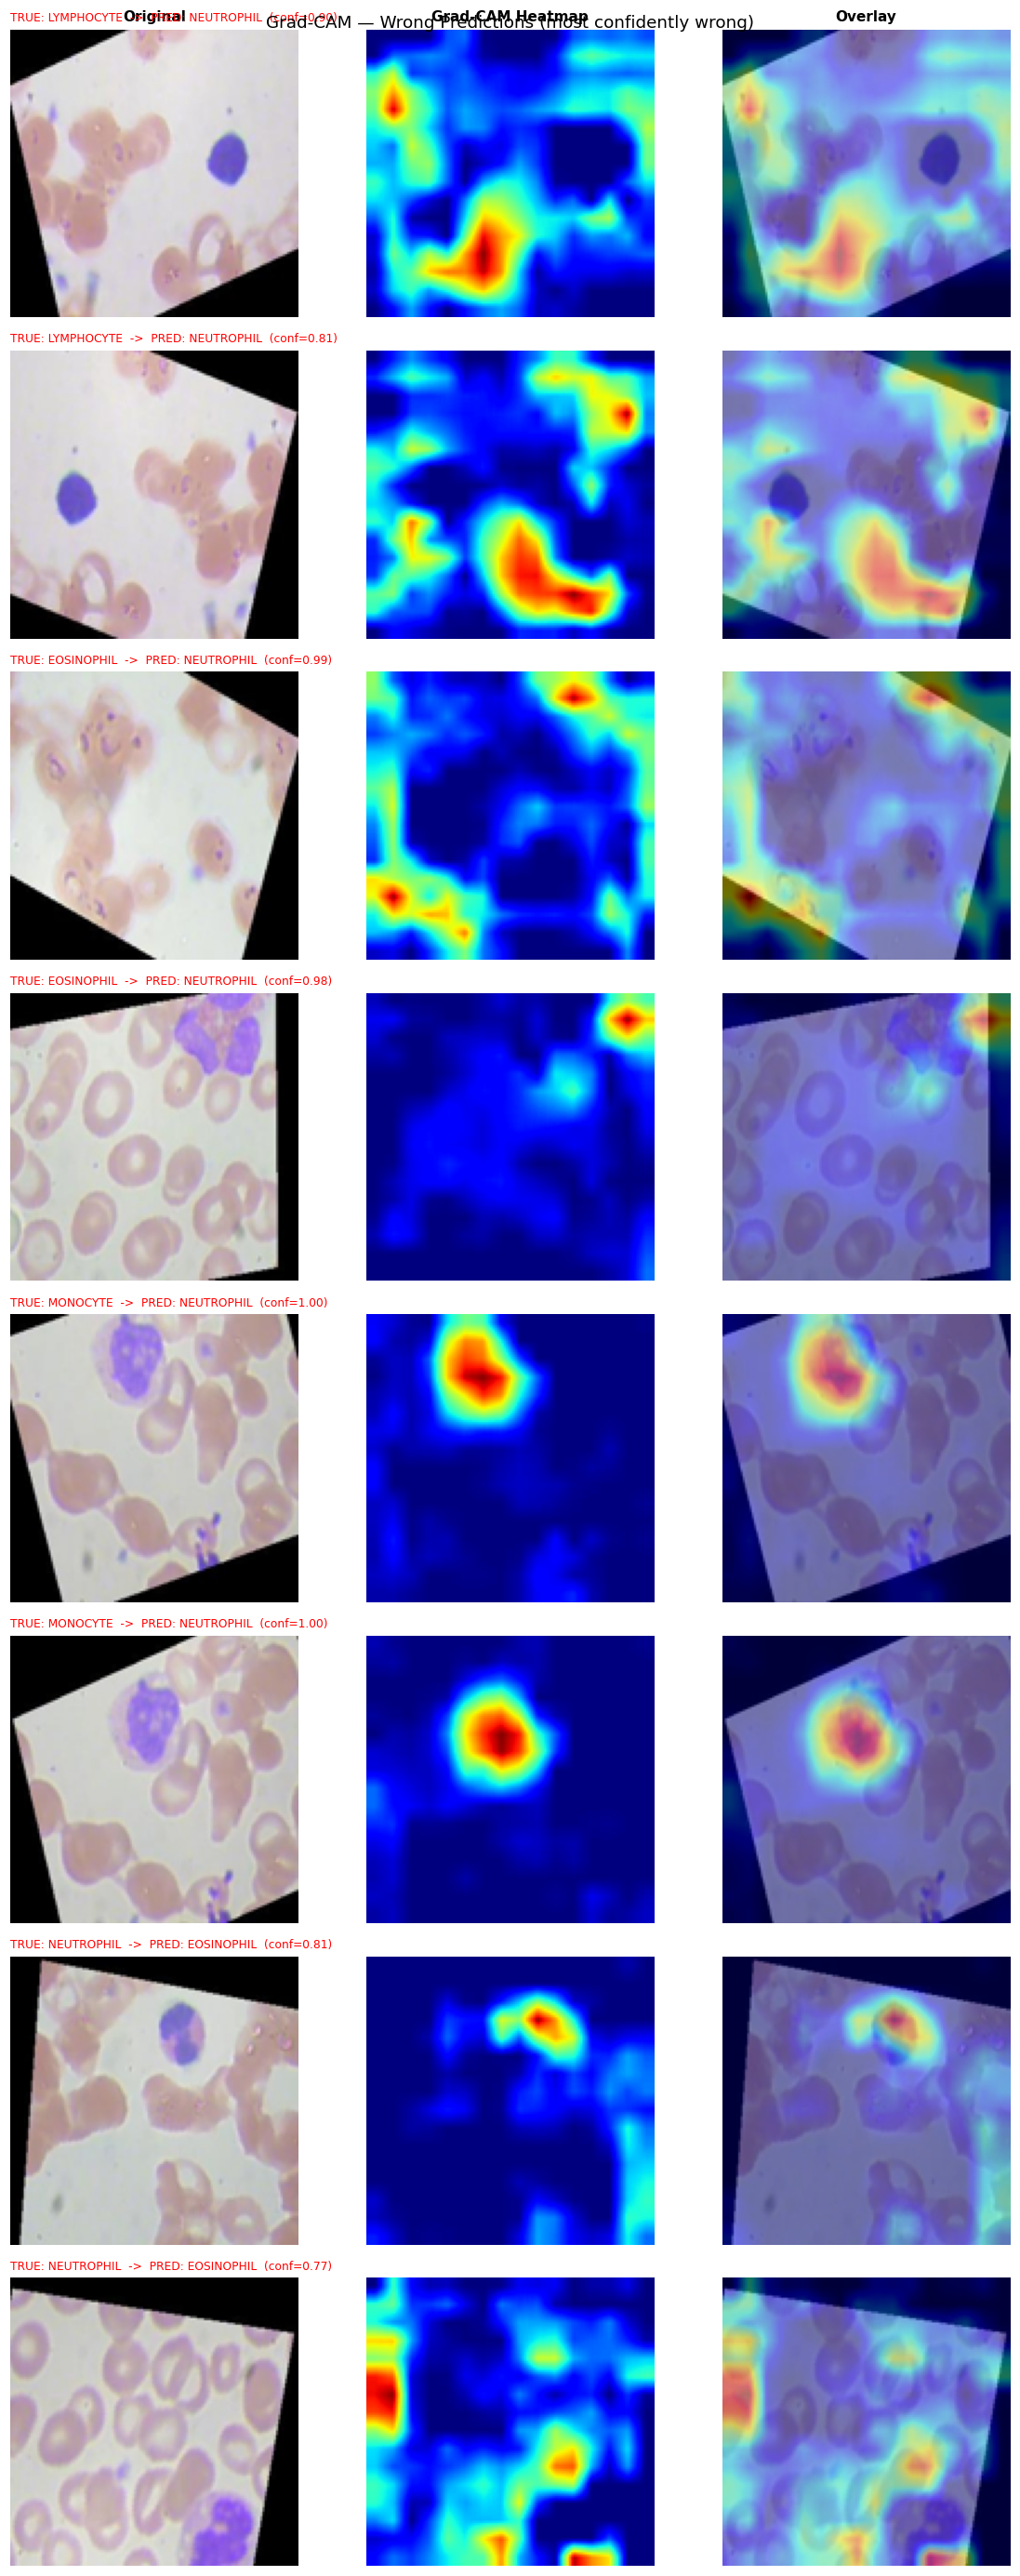

saved -> outputs/figures/phase4_04_gradcam_wrong.png


In [12]:
# Plot Grad-CAM for wrong predictions
n_wrong = len(wrong_samples)
fig, axes = plt.subplots(n_wrong, 3, figsize=(11, 3.2 * n_wrong))
if n_wrong == 1:
    axes = axes[np.newaxis, :]

axes[0, 0].set_title("Original",        fontsize=10, fontweight="bold")
axes[0, 1].set_title("Grad-CAM Heatmap", fontsize=10, fontweight="bold")
axes[0, 2].set_title("Overlay",          fontsize=10, fontweight="bold")

for row, (fp, t, p, conf) in enumerate(wrong_samples):
    img_input = preprocess_image(fp)
    heatmap, _ = make_gradcam_heatmap(img_input, class_idx=int(p))
    orig, overlay = overlay_gradcam(fp, heatmap)
    hm_display = np.array(Image.fromarray(np.uint8(255 * heatmap)).resize(IMG_SIZE, Image.BILINEAR))

    row_title = f"TRUE: {CLASSES[t]}  ->  PRED: {CLASSES[p]}  (conf={conf:.2f})"
    axes[row, 0].set_title(row_title, fontsize=8, color="red", loc="left")
    axes[row, 0].imshow(orig)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(hm_display, cmap="jet", vmin=0, vmax=255)
    axes[row, 1].axis("off")
    axes[row, 2].imshow(overlay)
    axes[row, 2].axis("off")

fig.suptitle("Grad-CAM — Wrong Predictions (most confidently wrong)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / "phase4_04_gradcam_wrong.png", bbox_inches="tight", dpi=150)
plt.show()
print("saved -> outputs/figures/phase4_04_gradcam_wrong.png")


### 4.3 Direct Comparison: Correct vs Wrong (same class)

Compare Grad-CAM overlays for a correctly-classified LYMPHOCYTE vs a LYMPHOCYTE that was
misclassified as NEUTROPHIL — the most frequent error in Phase 3.

In [13]:
# Build comparison figure:
# Left panel:  LYMPHOCYTE correctly predicted (high conf)
# Right panel: LYMPHOCYTE wrongly predicted as NEUTROPHIL
# Also add EOSINOPHIL pair (second most confused)

comparison_pairs = []

for focus_cls in [1, 0]:   # LYMPHOCYTE=1, EOSINOPHIL=0
    # Correct
    mask_ok = (y_true == focus_cls) & (y_pred == focus_cls)
    idxs_ok = np.where(mask_ok)[0]
    if len(idxs_ok) > 0:
        best_ok = idxs_ok[np.argmax(y_pred_proba[idxs_ok, focus_cls])]
        comparison_pairs.append((
            test_filepaths[best_ok], y_true[best_ok], y_pred[best_ok],
            y_pred_proba[best_ok, y_pred[best_ok]], 'CORRECT'
        ))

    # Wrong (predicted as NEUTROPHIL)
    mask_wr = (y_true == focus_cls) & (y_pred == 3)
    idxs_wr = np.where(mask_wr)[0]
    if len(idxs_wr) > 0:
        best_wr = idxs_wr[np.argmax(y_pred_proba[idxs_wr, 3])]
        comparison_pairs.append((
            test_filepaths[best_wr], y_true[best_wr], y_pred[best_wr],
            y_pred_proba[best_wr, y_pred[best_wr]], 'WRONG'
        ))

print(f'{len(comparison_pairs)} images selected for comparison')
for fp, t, p, c, label in comparison_pairs:
    print(f'  [{label}] TRUE={CLASSES[t]:<14} PRED={CLASSES[p]:<14} conf={c:.4f}')

4 images selected for comparison
  [CORRECT] TRUE=LYMPHOCYTE     PRED=LYMPHOCYTE     conf=1.0000
  [WRONG] TRUE=LYMPHOCYTE     PRED=NEUTROPHIL     conf=0.8956
  [CORRECT] TRUE=EOSINOPHIL     PRED=EOSINOPHIL     conf=1.0000
  [WRONG] TRUE=EOSINOPHIL     PRED=NEUTROPHIL     conf=0.9868


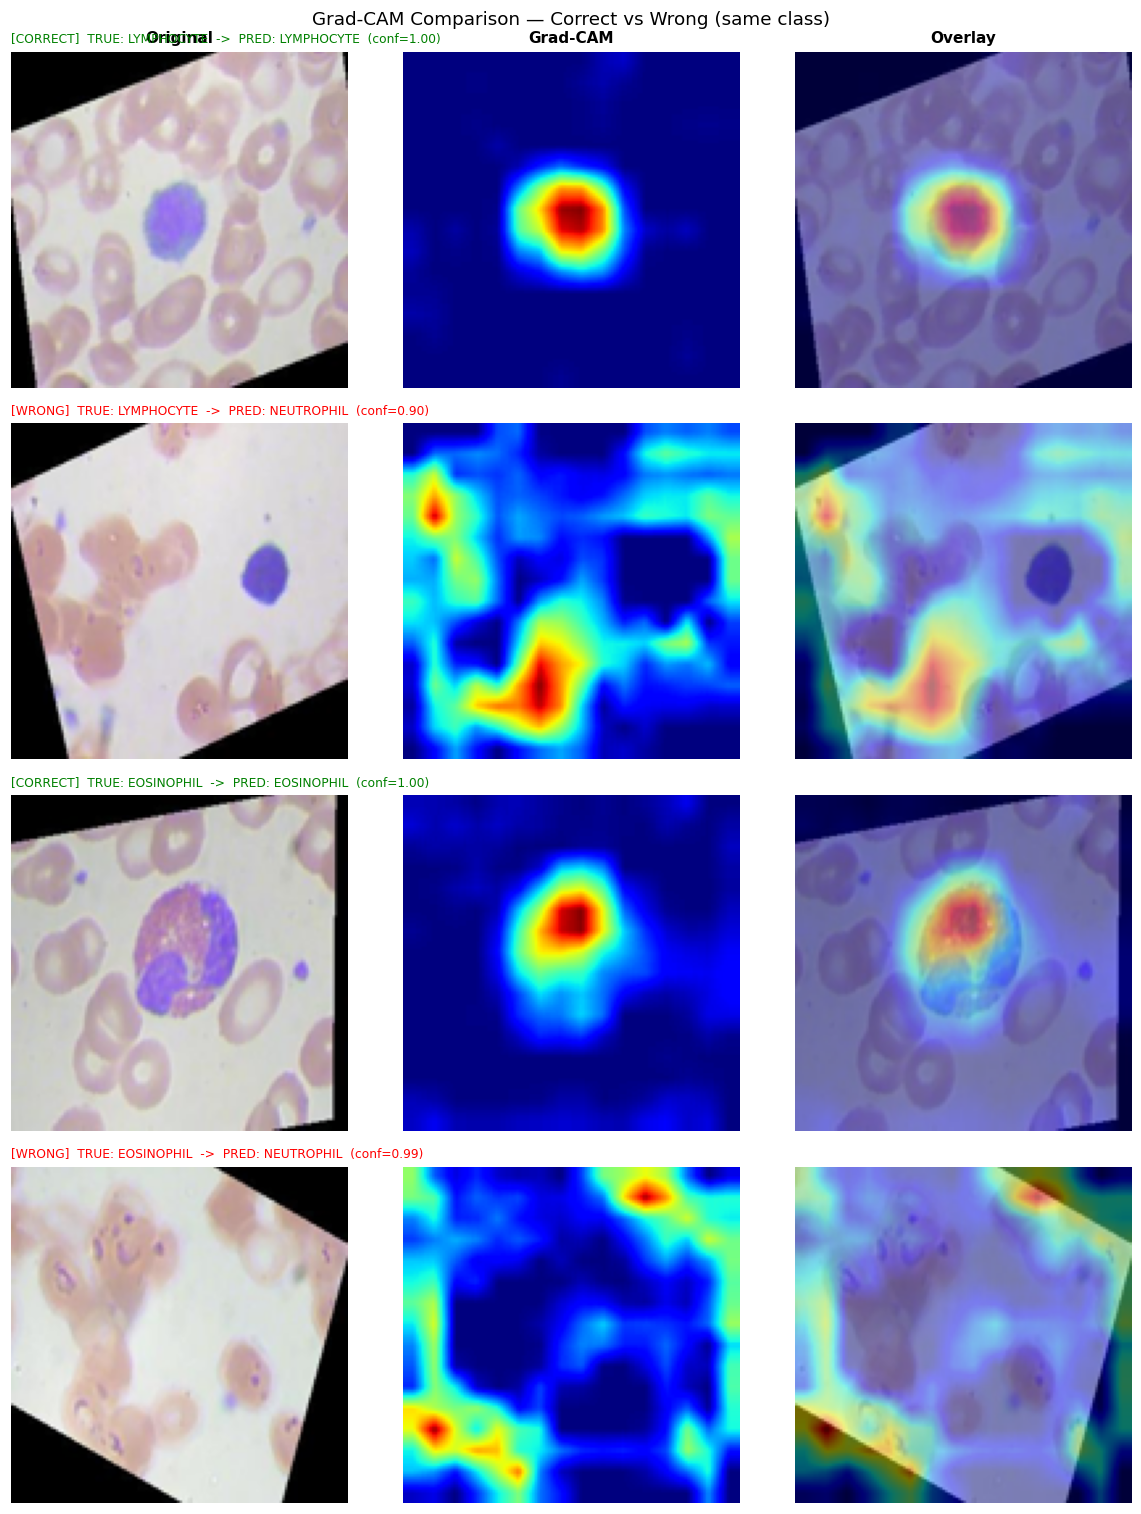

saved -> outputs/figures/phase4_05_gradcam_comparison.png


In [14]:
n_pairs = len(comparison_pairs)
fig, axes = plt.subplots(n_pairs, 3, figsize=(11, 3.5 * n_pairs))
if n_pairs == 1:
    axes = axes[np.newaxis, :]

axes[0, 0].set_title("Original",  fontsize=10, fontweight="bold")
axes[0, 1].set_title("Grad-CAM",  fontsize=10, fontweight="bold")
axes[0, 2].set_title("Overlay",   fontsize=10, fontweight="bold")

for row, (fp, t, p, conf, label) in enumerate(comparison_pairs):
    img_input = preprocess_image(fp)
    heatmap, _ = make_gradcam_heatmap(img_input, class_idx=int(p))
    orig, overlay = overlay_gradcam(fp, heatmap)
    hm_display = np.array(
        Image.fromarray(np.uint8(255 * heatmap)).resize(IMG_SIZE, Image.BILINEAR)
    )

    border_color = "green" if label == "CORRECT" else "red"
    row_title = f"[{label}]  TRUE: {CLASSES[t]}  ->  PRED: {CLASSES[p]}  (conf={conf:.2f})"

    axes[row, 0].set_title(row_title, fontsize=8, color=border_color, loc="left")
    axes[row, 0].imshow(orig)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(hm_display, cmap="jet", vmin=0, vmax=255)
    axes[row, 1].axis("off")
    axes[row, 2].imshow(overlay)
    axes[row, 2].axis("off")

fig.suptitle("Grad-CAM Comparison — Correct vs Wrong (same class)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / "phase4_05_gradcam_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("saved -> outputs/figures/phase4_05_gradcam_comparison.png")


## 5. Summary Analysis

In [15]:
# Compute per-class average heatmap activation region
# (fraction of image area with heatmap > 0.5 threshold)
print('Per-class Grad-CAM focus analysis')
print('(Fraction of image area with heatmap > 0.5)')
print('-' * 50)

for cls_idx in range(len(CLASSES)):
    # Take up to 20 correct predictions for this class
    mask   = (y_true == cls_idx) & (y_pred == cls_idx)
    idxs   = np.where(mask)[0][:20]
    if len(idxs) == 0:
        print(f'  {CLASSES[cls_idx]:<14}: no correct predictions')
        continue

    focus_fracs = []
    for idx in idxs:
        img_input = preprocess_image(test_filepaths[idx])
        hm, _     = make_gradcam_heatmap(img_input, class_idx=cls_idx)
        # Resize heatmap to IMG_SIZE before thresholding
        hm_full   = np.array(Image.fromarray(np.uint8(255 * hm)).resize(IMG_SIZE, Image.BILINEAR)) / 255.0
        focus_fracs.append((hm_full > 0.5).mean())

    print(f'  {CLASSES[cls_idx]:<14}: mean focus area = {np.mean(focus_fracs)*100:.1f}%  '
          f'(n={len(idxs)})')

print()
print('Note: a smaller focus area suggests the model found a specific, localised discriminative region.')
print('A large focus area (>50%) suggests the model uses diffuse context rather than a precise region.')

Per-class Grad-CAM focus analysis
(Fraction of image area with heatmap > 0.5)
--------------------------------------------------
  EOSINOPHIL    : mean focus area = 5.5%  (n=20)
  LYMPHOCYTE    : mean focus area = 4.5%  (n=20)
  MONOCYTE      : mean focus area = 4.9%  (n=20)
  NEUTROPHIL    : mean focus area = 5.8%  (n=20)

Note: a smaller focus area suggests the model found a specific, localised discriminative region.
A large focus area (>50%) suggests the model uses diffuse context rather than a precise region.


In [16]:
# Final summary printout
print('=' * 60)
print('  PHASE 4 INTERPRETABILITY — SUMMARY')
print('=' * 60)
print()
print('Model       :', BEST_MODEL)
print('Test acc    : 72.38%')
print('Grad-CAM target layer:', GRADCAM_LAYER.name)
print()
print('Figures saved:')
for fname in [
    'phase4_01_conv_filters.png',
    'phase4_02_feature_maps_eosinophil.png',
    'phase4_02_feature_maps_lymphocyte.png',
    'phase4_02_feature_maps_monocyte.png',
    'phase4_02_feature_maps_neutrophil.png',
    'phase4_03_gradcam_correct.png',
    'phase4_04_gradcam_wrong.png',
    'phase4_05_gradcam_comparison.png',
]:
    path = FIGS / fname
    status = 'OK' if path.exists() else 'MISSING'
    print(f'  [{status}] {fname}')

  PHASE 4 INTERPRETABILITY — SUMMARY

Model       : exp5_aug_bn_drop05_b64_best.keras
Test acc    : 72.38%
Grad-CAM target layer: activation_23

Figures saved:
  [OK] phase4_01_conv_filters.png
  [OK] phase4_02_feature_maps_eosinophil.png
  [OK] phase4_02_feature_maps_lymphocyte.png
  [OK] phase4_02_feature_maps_monocyte.png
  [OK] phase4_02_feature_maps_neutrophil.png
  [OK] phase4_03_gradcam_correct.png
  [OK] phase4_04_gradcam_wrong.png
  [OK] phase4_05_gradcam_comparison.png
